In [1]:
import requests
import pandas as pd
from io import StringIO
import time
import numpy as np
import matplotlib.pyplot as plt

# Get data via API

In [2]:
BASE = "https://wisportal.erdc.dren.mil/data"

# Get all 4000 stations
all_stations = requests.get(f"{BASE}/api/stations").json()

# Filter with two bounding boxes to get buoys in Green Bay
stations = [
    s for s in all_stations
    if ((-88.5 <= s["longitude"] <= -87.5)
    and (44.5 <= s["latitude"] <= 45)) or
    ((-87.5 <= s["longitude"] <= -87.2)
     and (45 <= s["latitude"] <= 45.34))
]

# Sanity Check
print("Number of Stations: ", len(stations))

# Assemble pd.DataFrame of desired values
# Instantiate rows to collect mini dataframes

rows = []

# Iterate through stations to request info we want
for i, st in enumerate(stations):
    # Get station id for debugging
    station_id = st["identifier"]

    # Create request
    r = requests.get(
        f"{BASE}/api/station/data",
        params={
            "url":st['services']['url'],                                                # Endpoint where data exists
            "variables": "windSpeed,windDirection,waveTp,waveHs,waveMeanDirection",     # Info we want (waves and wind)
            "format":"csv",                                                             # Get it in csv
            "time":"2024-07-27T12:00:00/2024-07-27T12:00:00"                            # Snapshot at noon on race day, 2024
        },
    )

    # Safety stop
    if r.status_code != 200:
        print(f"{i}: station {station_id} bad status {r.status_code}")

    # Strip spacing characters, another safety stop
    text = r.text.strip()
    if not text:
        print(f"{i}: station {station_id} empty response")
        continue

    # Create mini df, add station_id feature, and add to rows
    df = pd.read_csv(StringIO(text))
    df["station_id"] = station_id
    rows.append(df)

    # Give server a break
    time.sleep(0.1)

all_data = pd.concat(rows, ignore_index=True)
print(all_data.head())
all_data.to_csv('data/green_bay_wind_snapshot.csv', index=False)

Number of Stations:  41
                  time    lat    lon  windDirection  windSpeed  \
0  2024-07-27 12:00:00  45.24 -87.20          214.0   5.203125   
1  2024-07-27 12:00:00  45.24 -87.24          214.0   5.101562   
2  2024-07-27 12:00:00  45.24 -87.28          214.0   4.898438   
3  2024-07-27 12:00:00  45.20 -87.28          213.0   4.898438   
4  2024-07-27 12:00:00  45.16 -87.28          213.0   4.796875   

   waveMeanDirection    waveTp    waveHs station_id  
0              220.0  2.398438  0.273438    ST94144  
1              217.0  2.390625  0.250000    ST94145  
2              213.0  2.398438  0.242188    ST94146  
3              210.0  2.578125  0.218750    ST94147  
4              217.0  2.640625  0.257812    ST94148  


# Visualization

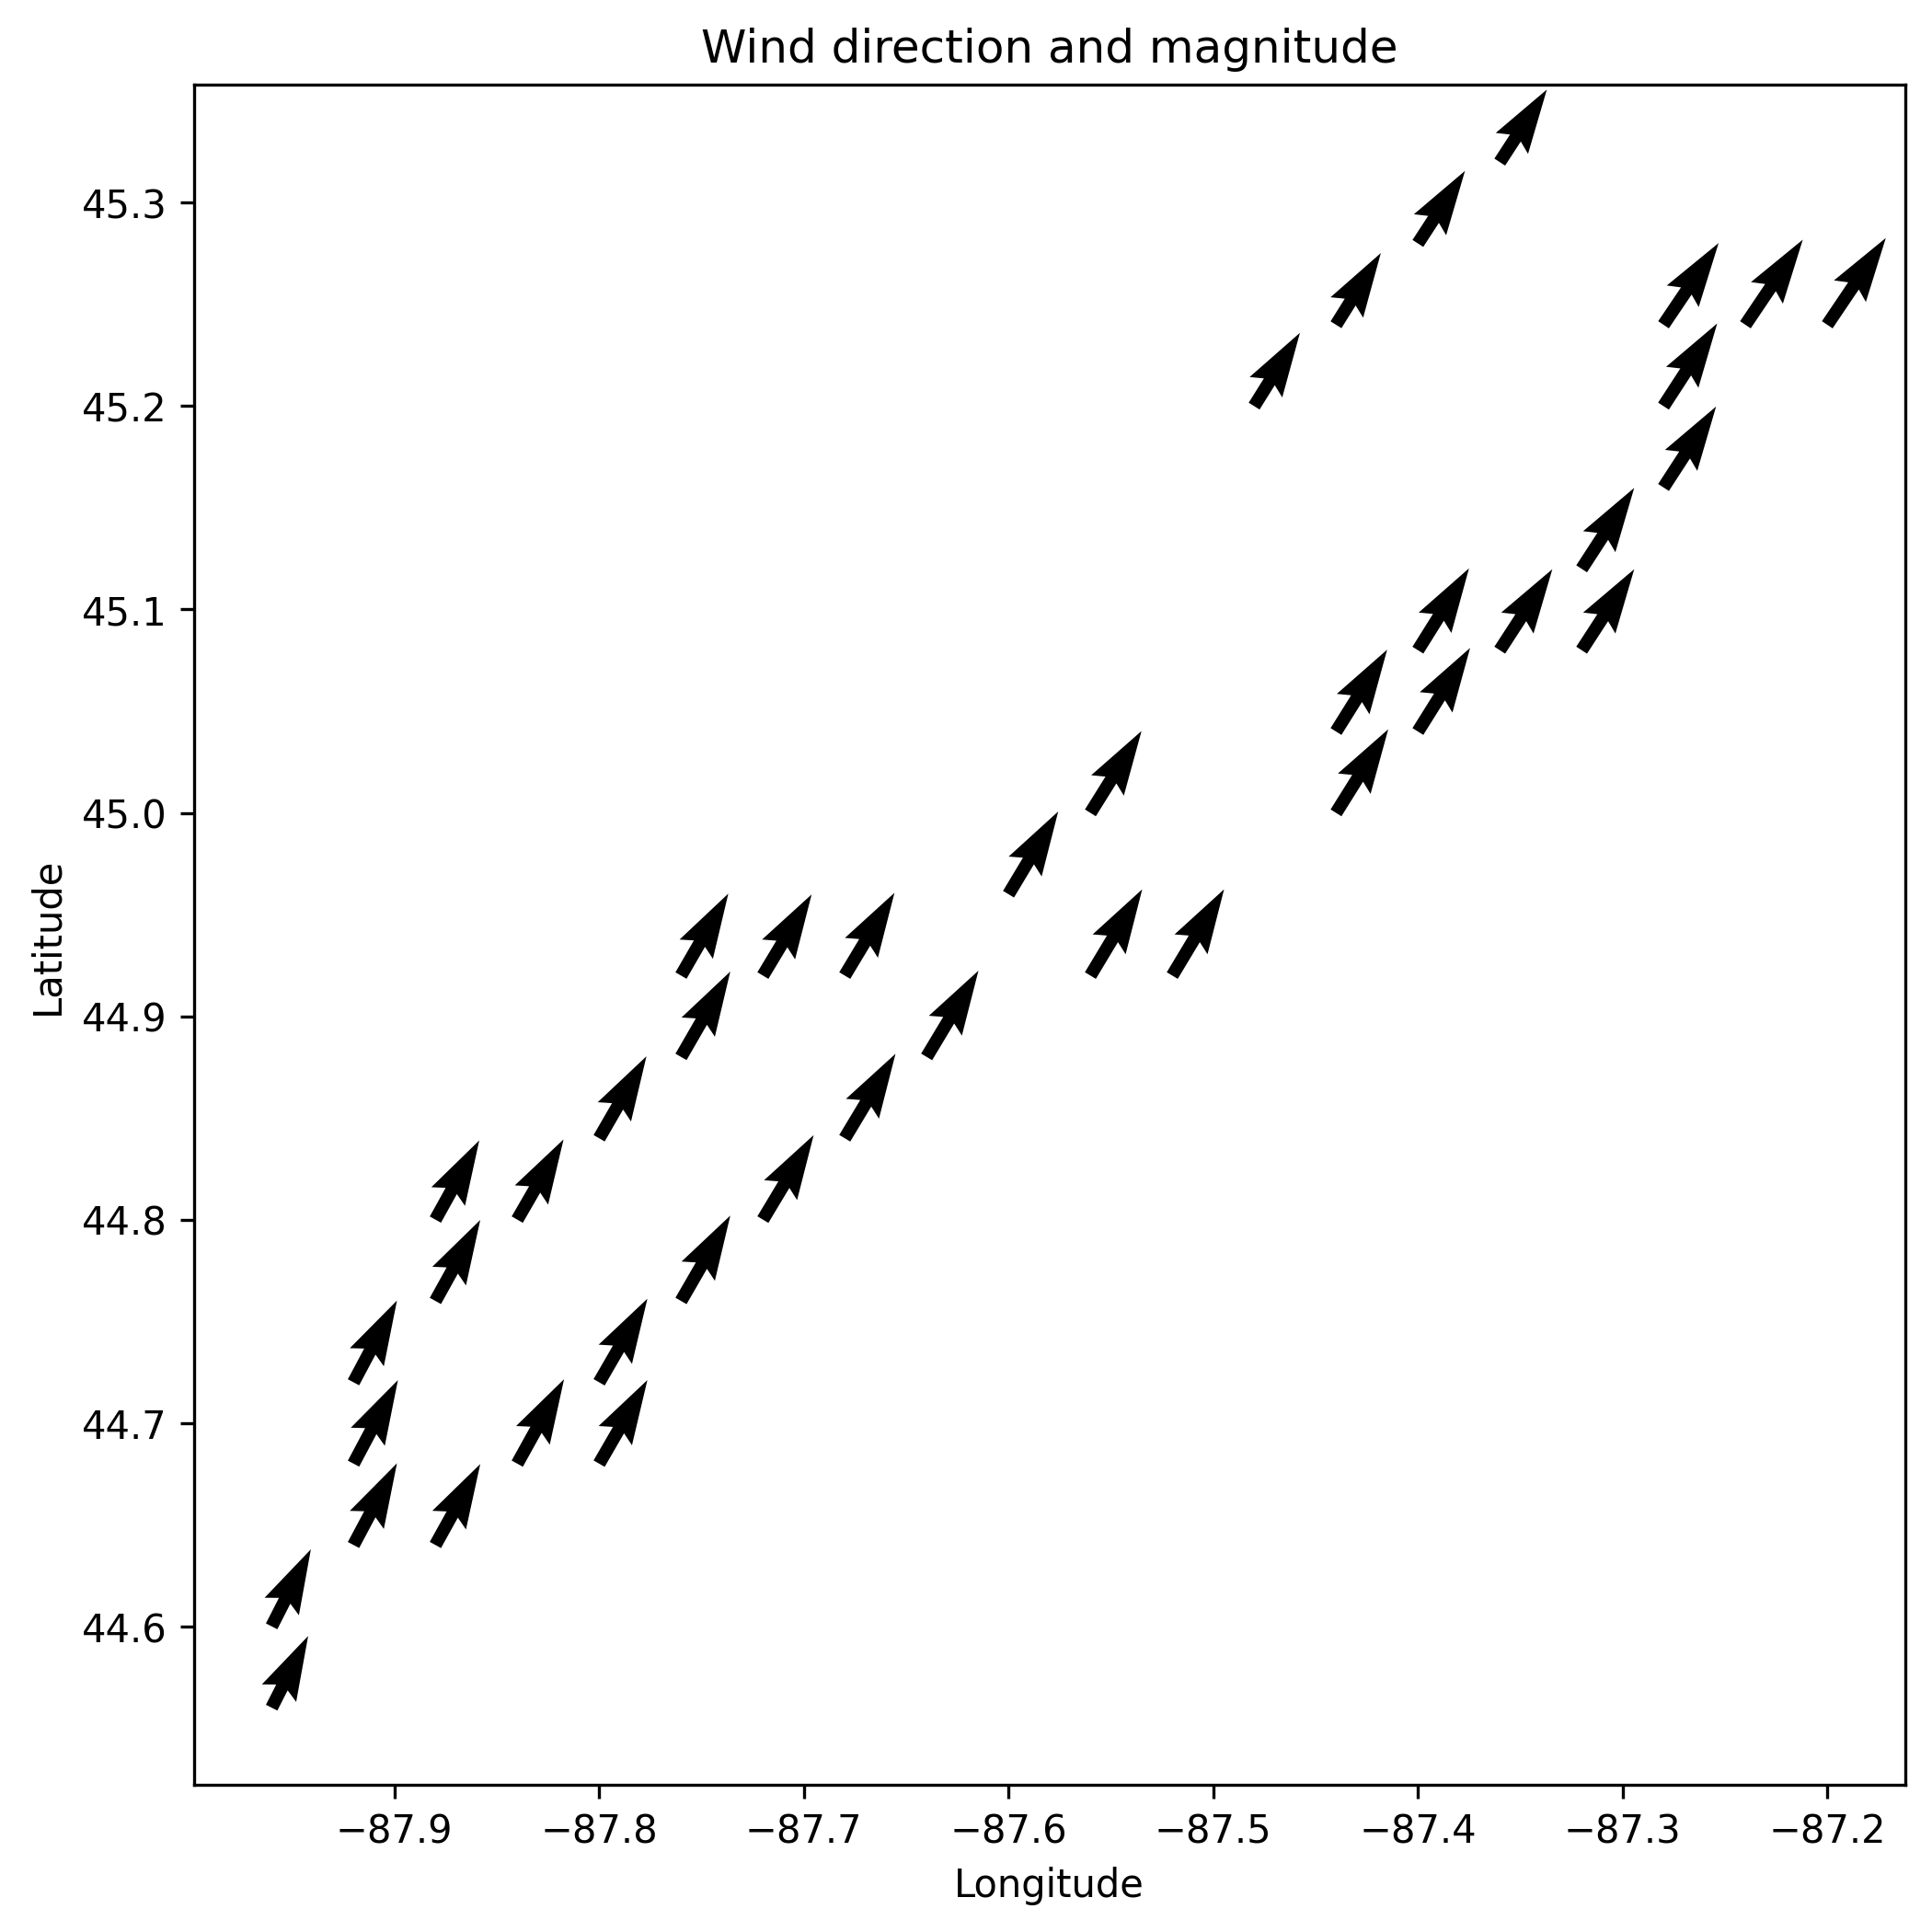

In [3]:
# Get coordinate, angle, and speed data for wind
X, Y, theta, speed = all_data['lon'], all_data['lat'], np.deg2rad(all_data['windDirection']), all_data['windSpeed']

# Get x and y components of wind
U = -speed * np.sin(theta)
V = -speed * np.cos(theta)

# Plot as quiver plot
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
ax.quiver(X, Y, U, V)
ax.set(title="Wind direction and magnitude", xlabel="Longitude", ylabel="Latitude")

plt.show()


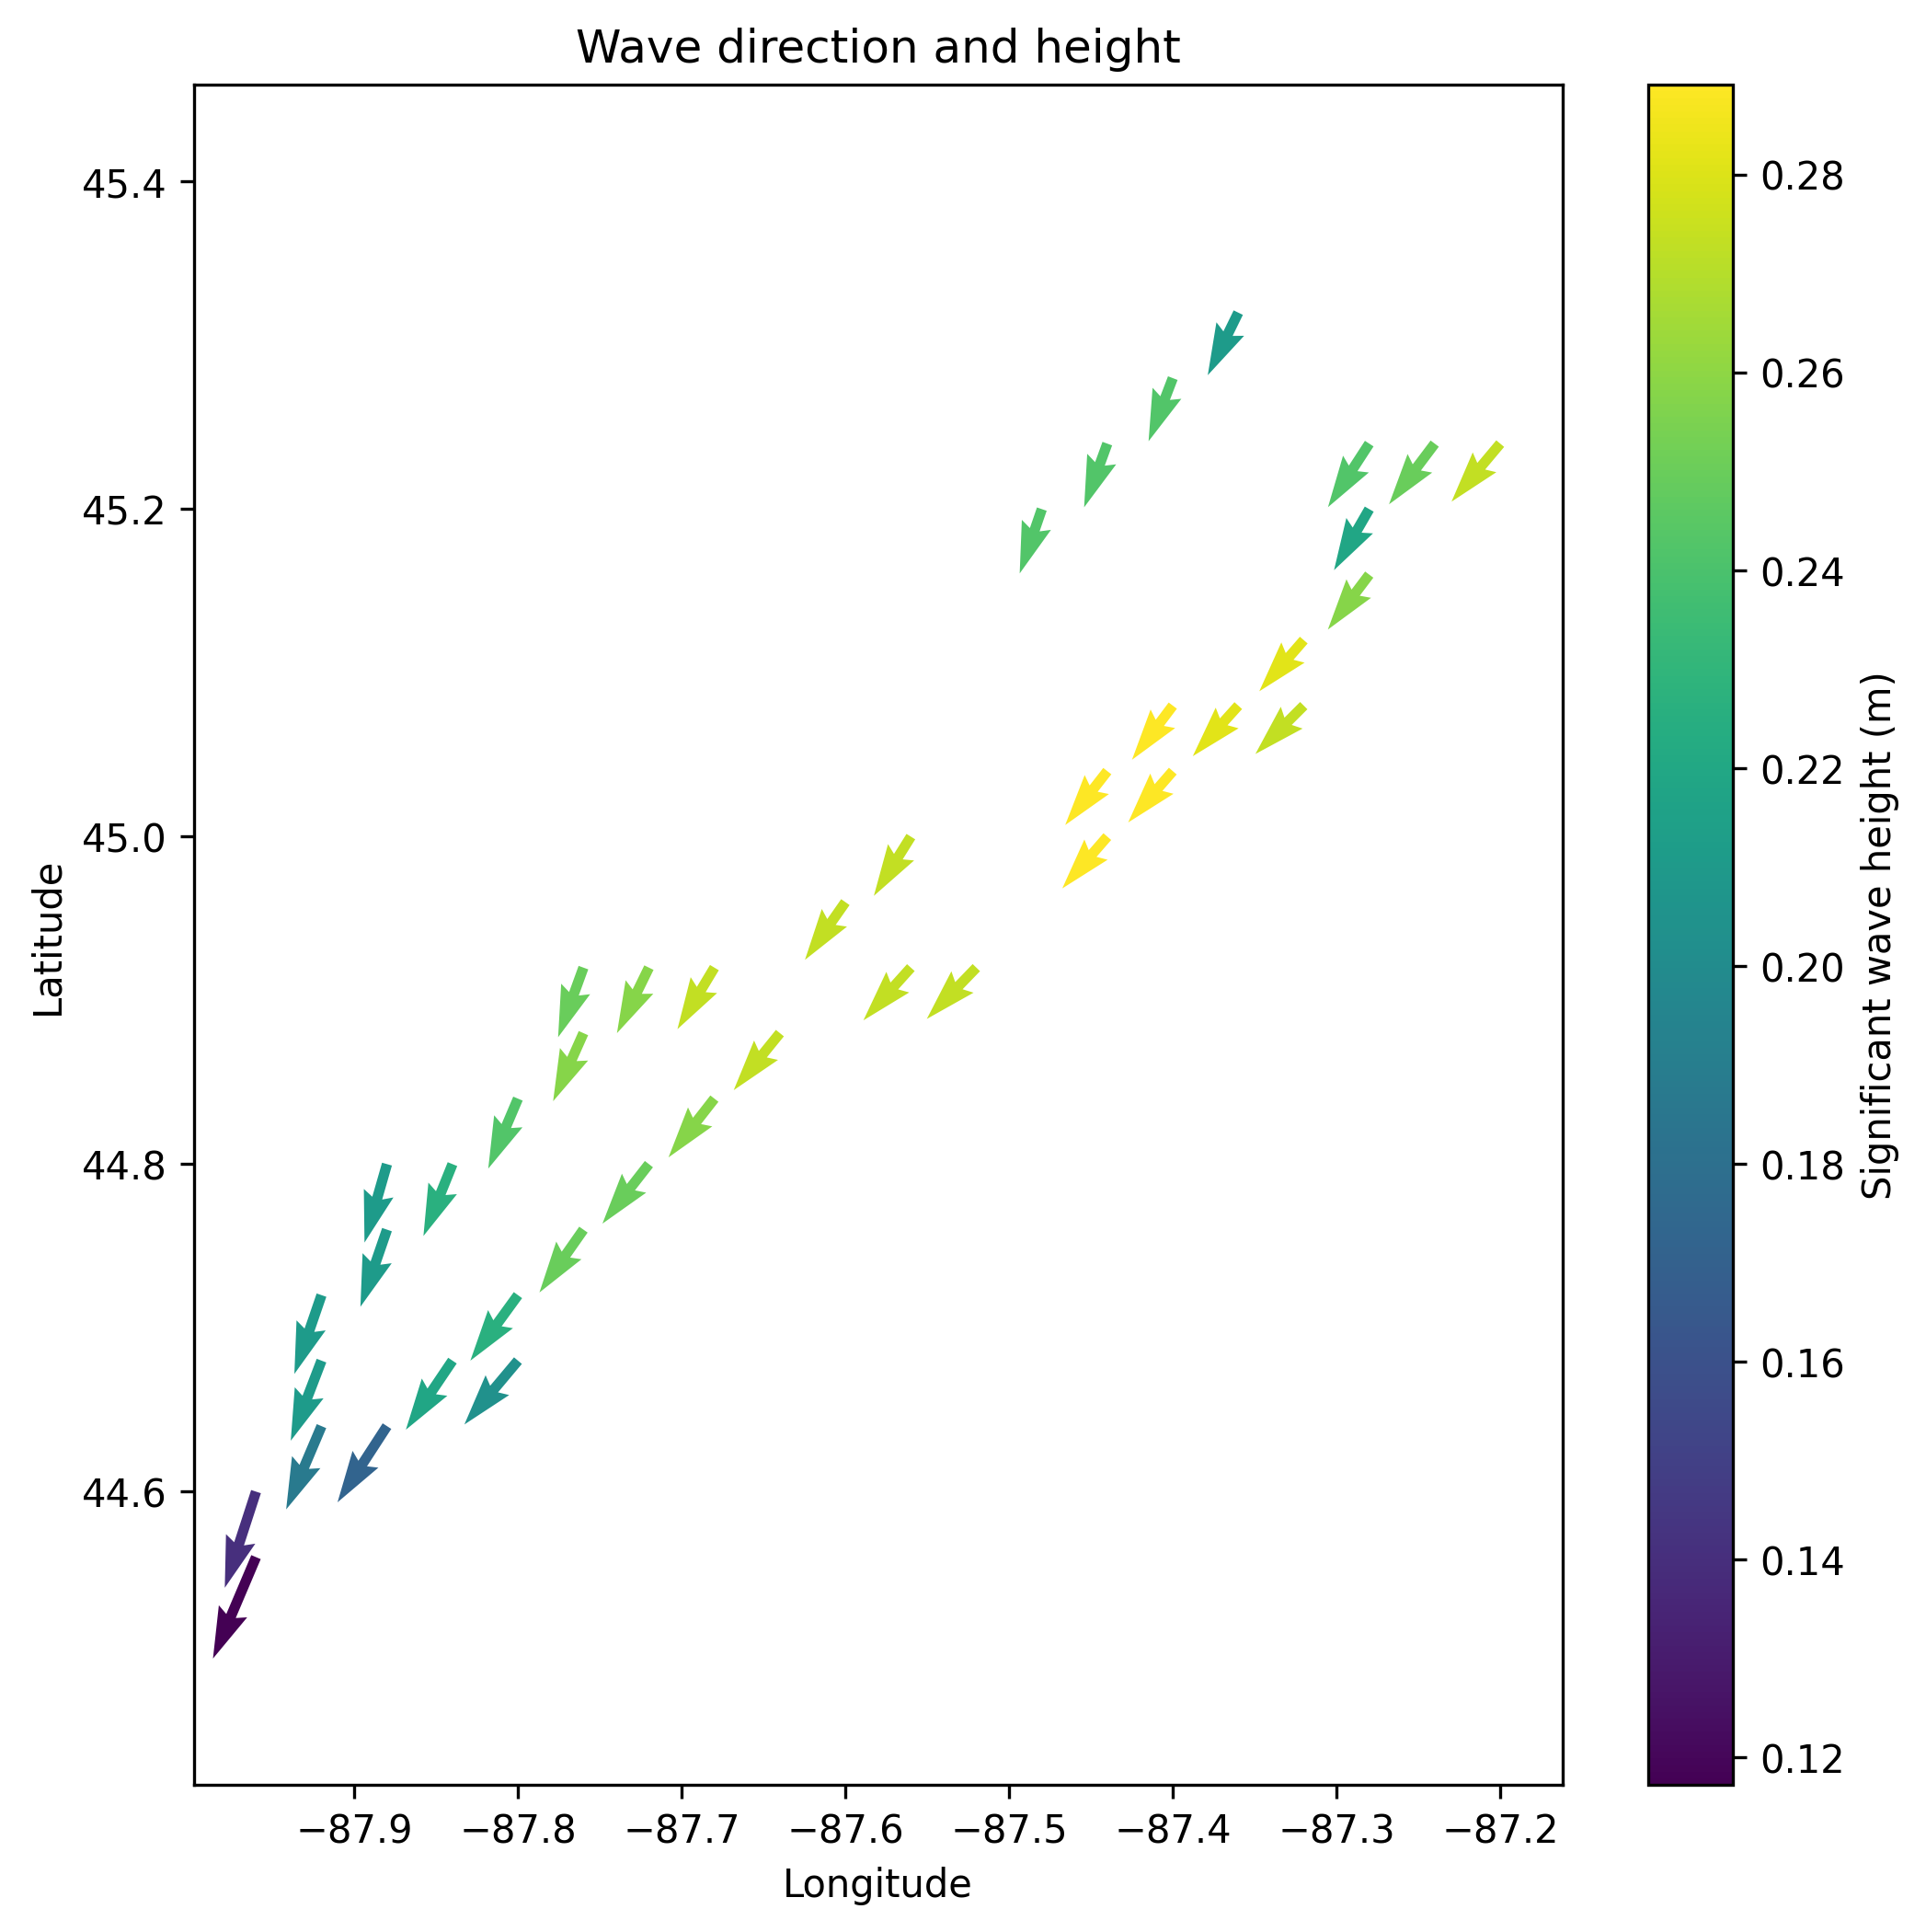

In [4]:
# Get coordinate, angle, height, and period data for waves
X, Y, theta, H, tp = all_data["lon"].to_numpy(), all_data["lat"].to_numpy(), np.deg2rad(all_data["waveMeanDirection"].to_numpy()), all_data["waveHs"].to_numpy(), all_data['waveTp'].to_numpy()

# Get x and y components for waves -- I divided to get frequency, not sure if that's right
U = np.sin(theta) / tp
V = np.cos(theta) / tp

# Plot quiverplot

fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
q = ax.quiver(X, Y, U, V, H)
fig.colorbar(q, ax=ax, label="Significant wave height (m)")

ax.set(title="Wave direction and height", xlabel="Longitude", ylabel="Latitude")
ax.axis("equal")

plt.show()

# Interpolation

In [5]:
import numpy as np
from scipy.interpolate import RBFInterpolator

X, Y, theta, speed = all_data['lon'], all_data['lat'], np.deg2rad(all_data['windDirection']), all_data['windSpeed']

u, v = -speed * np.sin(theta), -speed * np.cos(theta)

# coordinates
y = np.column_stack([X, Y])

u_interp = RBFInterpolator(y, u, kernel="thin_plate_spline", smoothing=0.0)
v_interp = RBFInterpolator(y, v, kernel="thin_plate_spline", smoothing=0.0)

# evaluate on new points
X_eval, Y_eval = np.meshgrid(np.linspace(-88, -87.1, 15), np.linspace(44.5, 45.4, 15))

eval = np.vstack([X_eval.ravel(), Y_eval.ravel()]).T

u_new = u_interp(eval).reshape(X_eval.shape)
v_new = v_interp(eval).reshape(X_eval.shape)

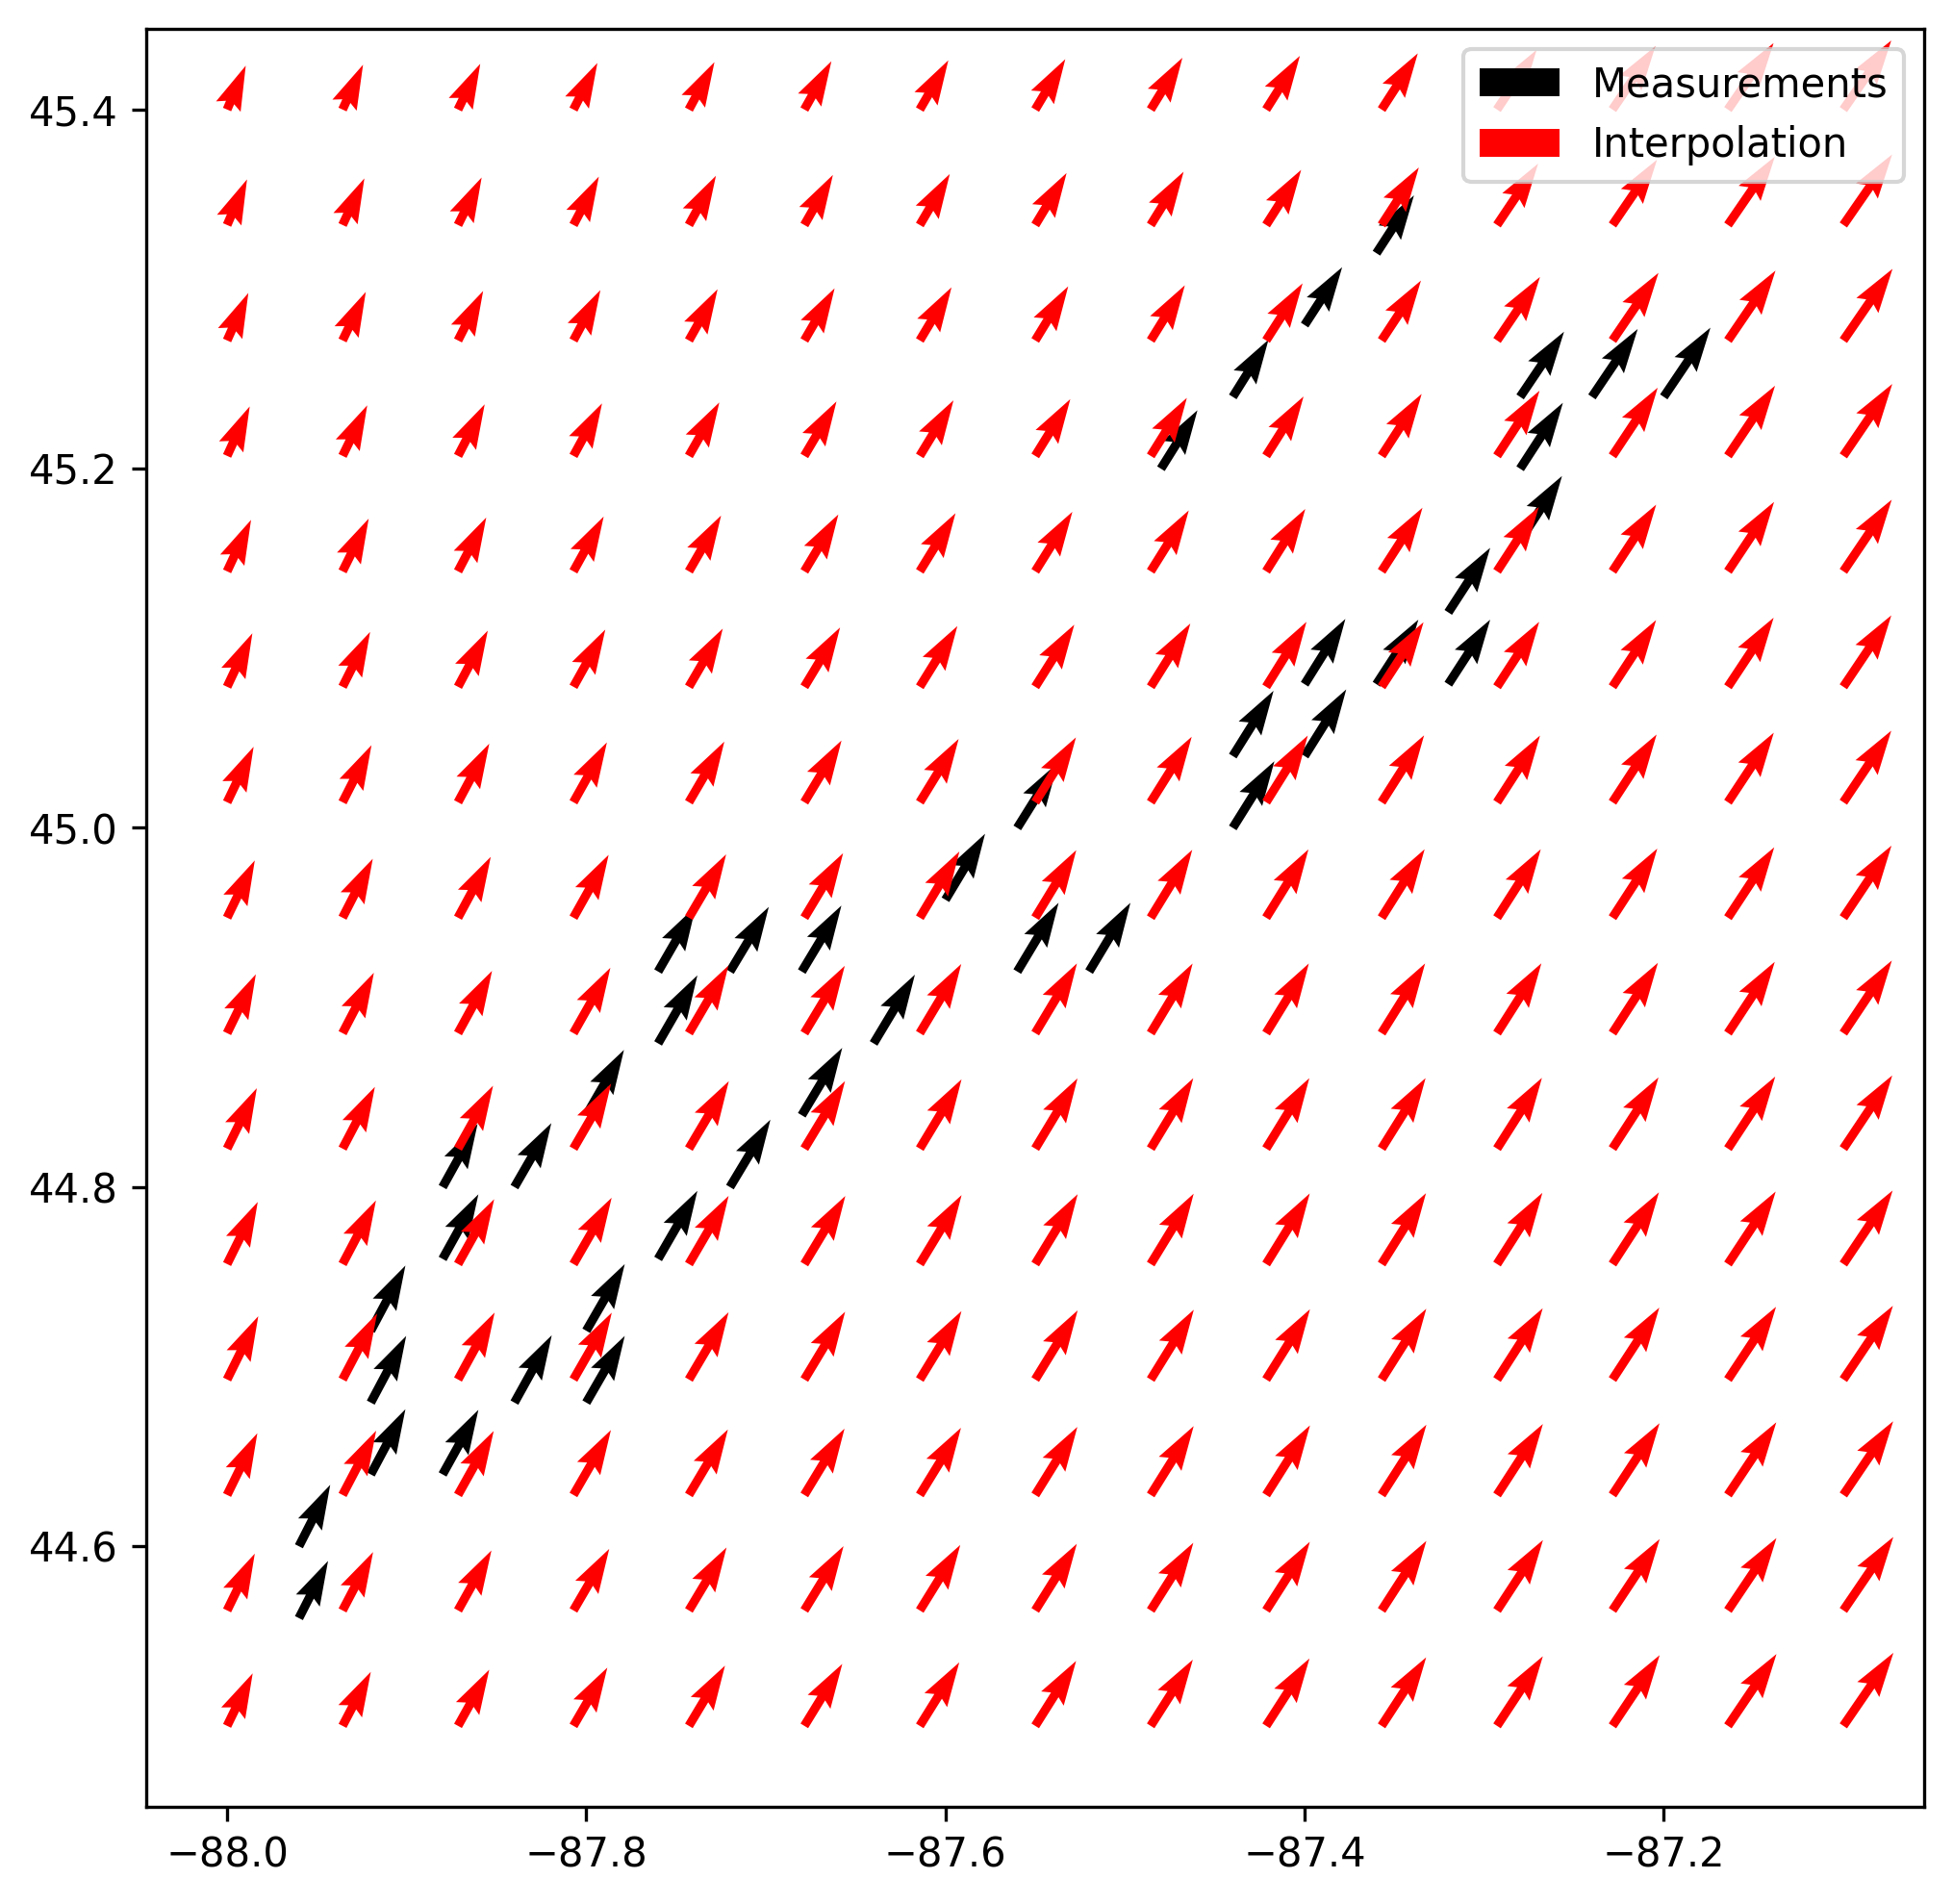

In [6]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

mag_all = np.hstack([
    np.sqrt(u**2 + v**2),
    np.sqrt(u_new.ravel()**2 + v_new.ravel()**2)
])

scale = np.max(mag_all) / 0.05

ax.quiver(X, Y, u, v, color='k', scale=scale, width=0.005, label="Measurements")
ax.quiver(X_eval, Y_eval, u_new, v_new, color='r', scale=scale, width=0.005, label="Interpolation")
ax.legend()

ax.set_aspect('equal')
plt.show()

## Waves (current)

In [7]:
import numpy as np
from scipy.interpolate import RBFInterpolator

X, Y, theta, speed = all_data['lon'], all_data['lat'], np.deg2rad(all_data['waveMeanDirection'].to_numpy()), 1 / all_data['waveTp'].to_numpy()

u, v = speed * np.sin(theta), speed * np.cos(theta)

# coordinates
y = np.column_stack([X, Y])

u_interp = RBFInterpolator(y, u, kernel="thin_plate_spline", smoothing=0.0)
v_interp = RBFInterpolator(y, v, kernel="thin_plate_spline", smoothing=0.0)

# evaluate on new points
X_eval, Y_eval = np.meshgrid(np.linspace(-88, -87.1, 15), np.linspace(44.5, 45.4, 15))

eval = np.vstack([X_eval.ravel(), Y_eval.ravel()]).T

u_new = u_interp(eval).reshape(X_eval.shape)
v_new = v_interp(eval).reshape(X_eval.shape)

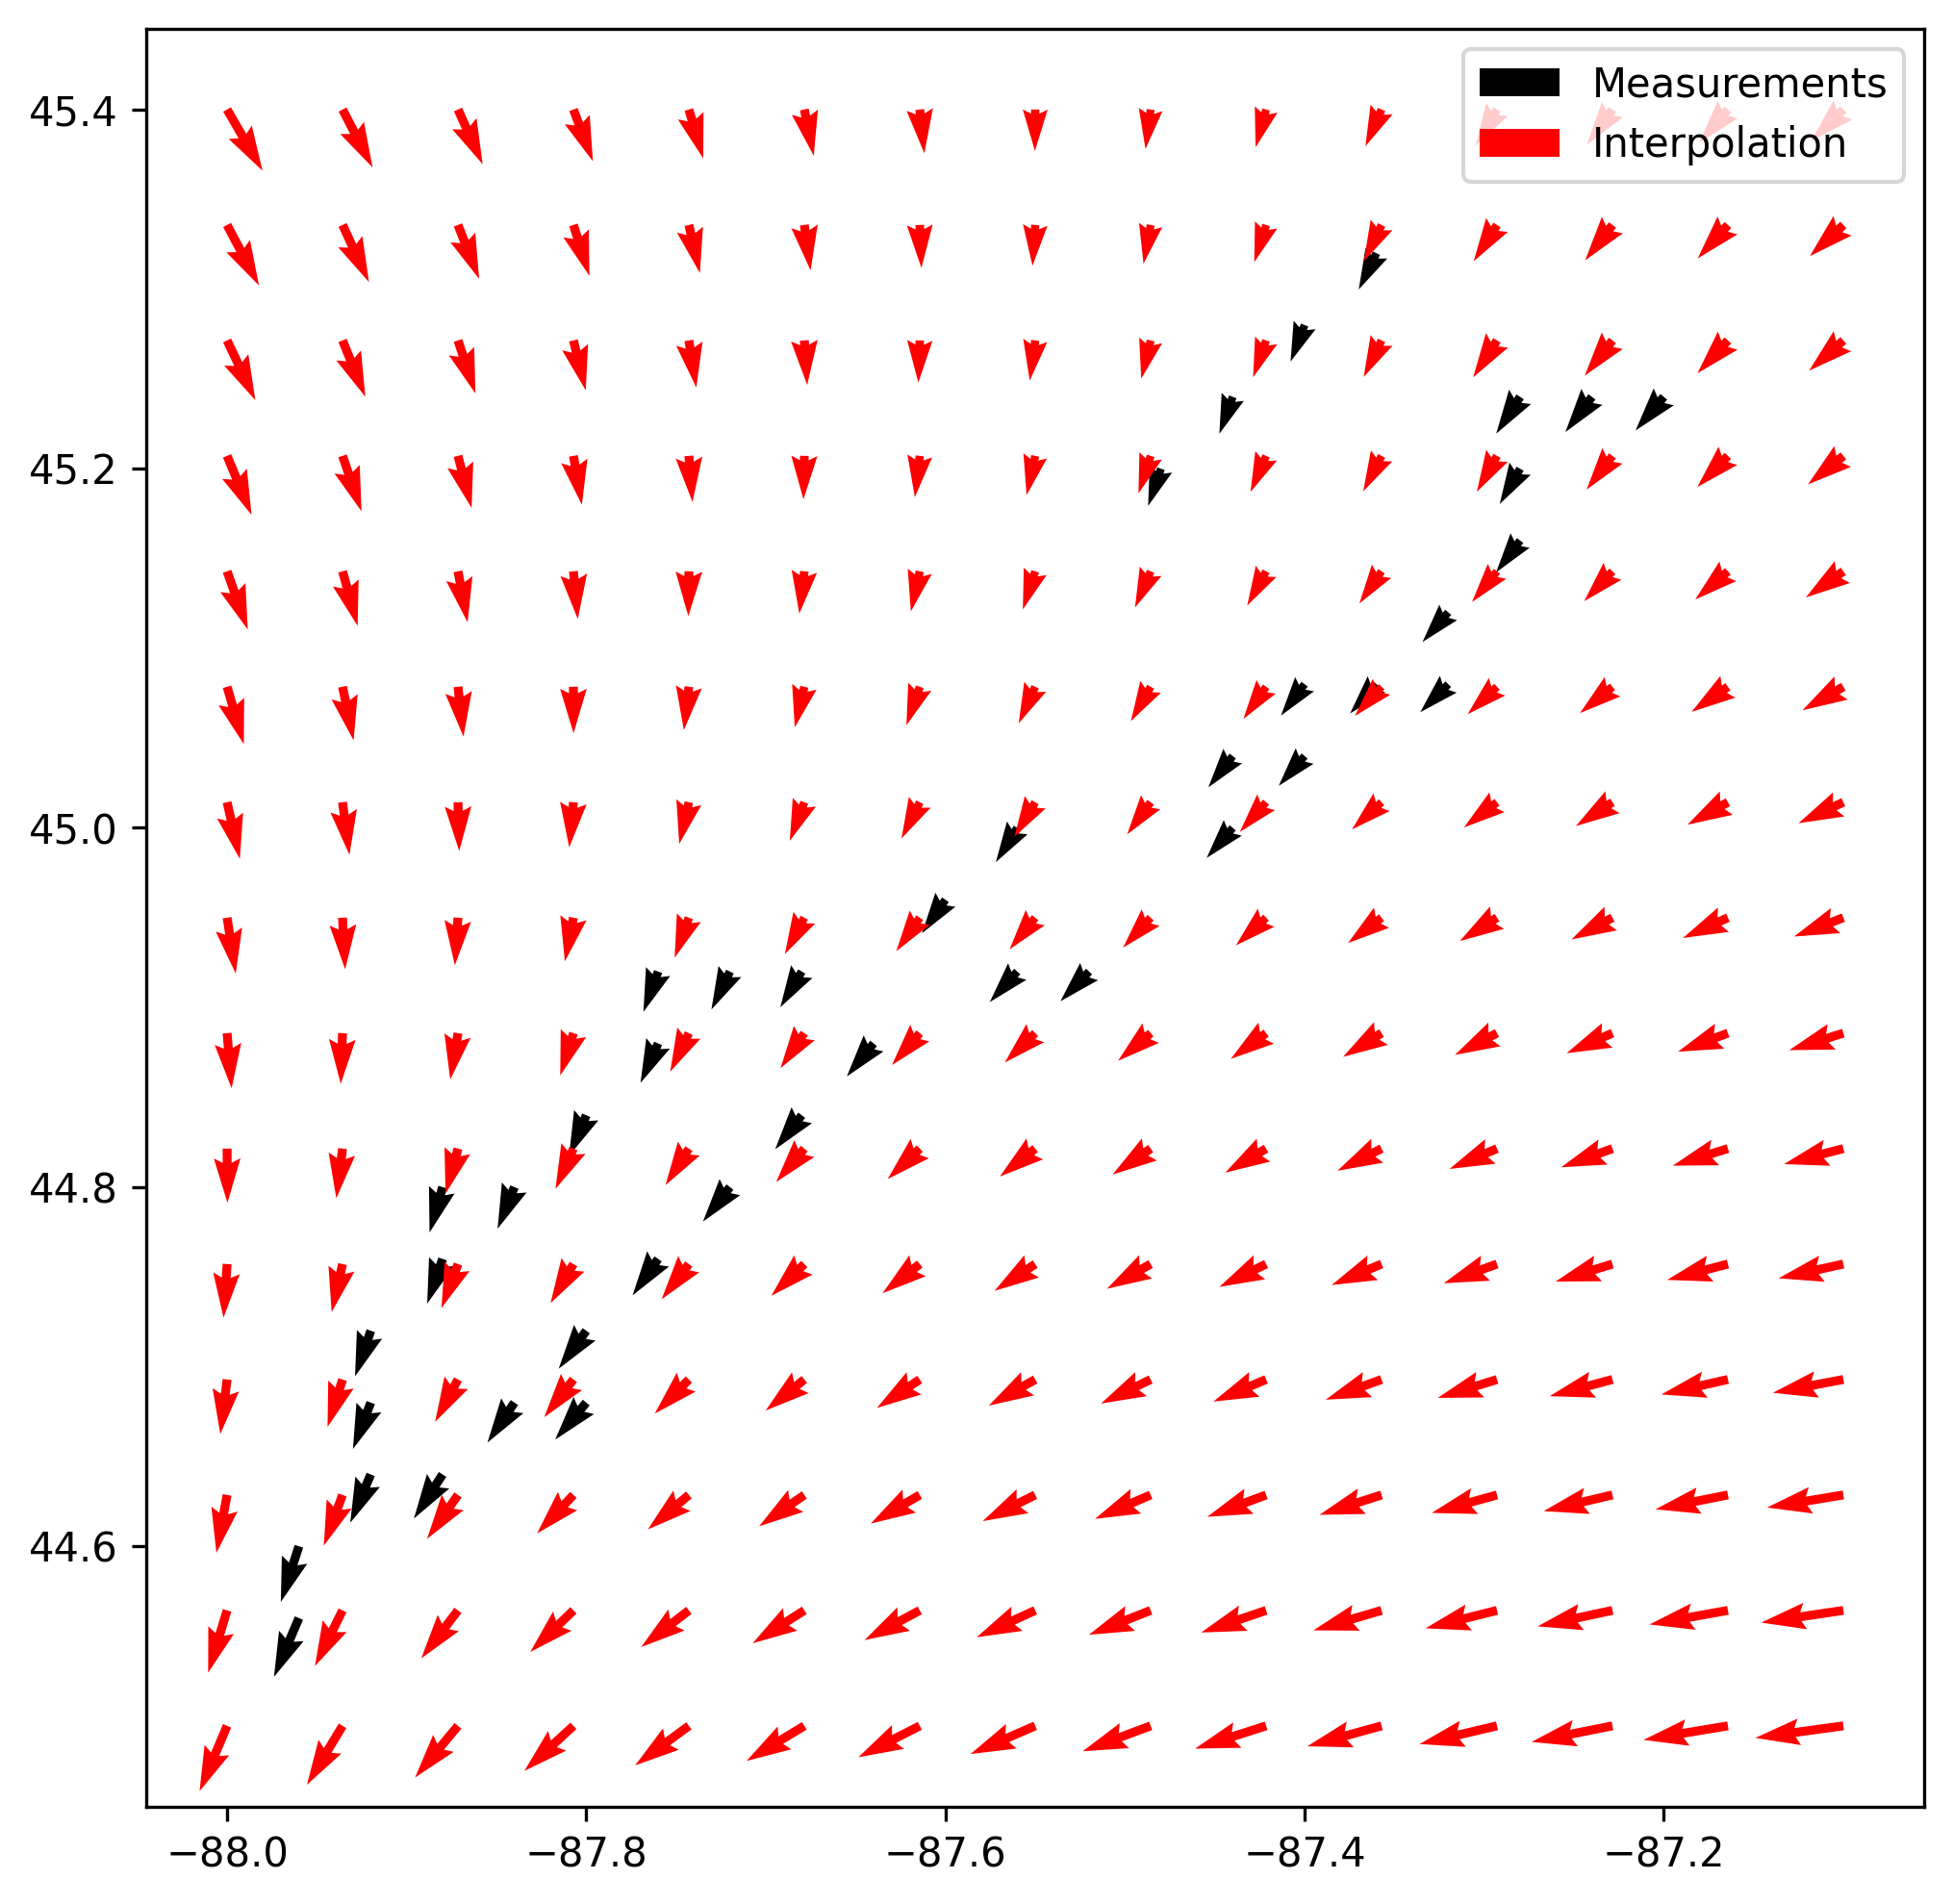

In [8]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

mag_all = np.hstack([
    np.sqrt(u**2 + v**2),
    np.sqrt(u_new.ravel()**2 + v_new.ravel()**2)
])

scale = np.max(mag_all) / 0.05

ax.quiver(X, Y, u, v, color='k', scale=scale, width=0.005, label="Measurements")
ax.quiver(X_eval, Y_eval, u_new, v_new, color='r', scale=scale, width=0.005, label="Interpolation")
ax.legend()

ax.set_aspect('equal')
plt.show()